# Memory Model

It describes how objects are created, referenced, shared, modified, and destroyed during the program's execution.

## Namespace

Unlike C/C++, CPython bind address to the obj and a variable is just a label referencing to the address. CPython uses dictionary to maintain namespaces i.e., 
- globals()         // the modules namespace
- locals()          // the current frame's namespace
- obj.__dict__.     // object's own namespace


> Python has one data structure for all naming: the dict. Modules, functions, and objects each carry one, and "scope" is just the order in which those dicts are searched.

# Variable assignment

```py
a = [1, 2]
b = a 
```

Here `a` & `b` are pointing @ `list [1, 2]`. Both are type independent, type is tied to the object not variable or label. Hence, that is the bottleneck of CPython that it struggles with speed, during PVM execution CPython resolves types which makes execution slow conversely to static typed languages. However, modern approaches uses two-tier approaches to resolve it but still the bottleneck exist.

The following picture can help you visualize the memory model correctly.

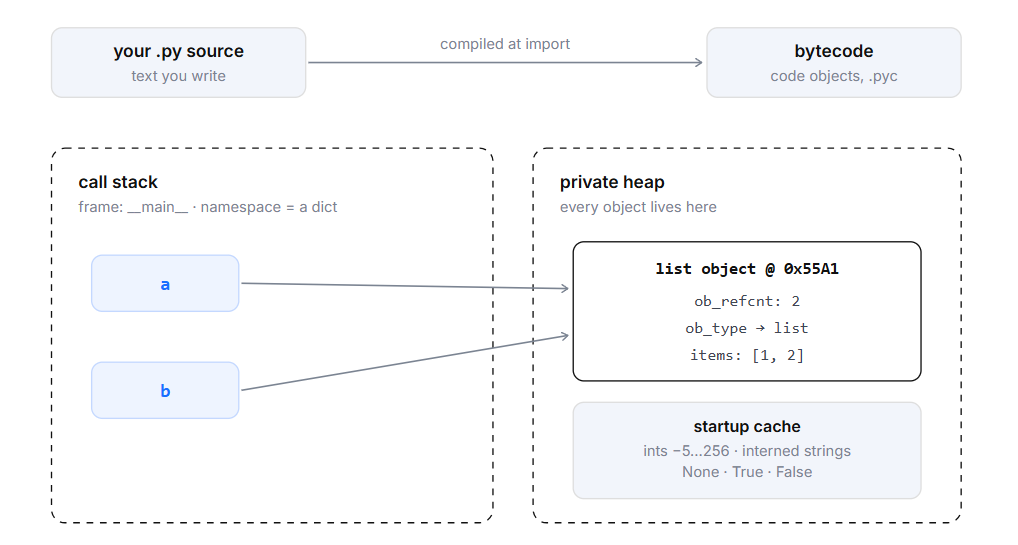

- **ob_refcnt**: notes down the reference count of `this object`. Goes up when a new reference is made, down when one disappears. Hits zero → the object is destroyed immediately. 

- **ob_type**: why the object knows its own type and the variable doesn't. This one pointer is what makes dynamic typing work.

- **Payload**: for an int, the digits; for a list, an array of references to other objects (a Python list is essentially a std::vector<PyObject*>).

## globals()

In [10]:
x = 5
lst = [1, 2]

# your variables, sitting in a plain dict
print(globals())

# scroll to end to see the actual x and lst in dictionary.

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', '# global()\n\nx = 5\nlst = [1, 2]\n\nprint(globals())', '# global()\n\nx = 5\nlst = [1, 2]\n\nprint(globals())\n# scroll to end to see the actual x and lst in dictionary.', 'globals()["z"] = 99   # write a key into the dict by hand...\nprint(z)', '# global()\n\nx = 5\nlst = [1, 2]\n\n# your variables, sitting in a plain dict\nprint(globals())\n# scroll to end to see the actual x and lst in dictionary.', '# global()\n\nx = 5\nlst = [1, 2]\n\n# your variables, sitting in a plain dict\nprint(globals())\n\n# scroll to end to see the actual x and lst in dictionary.', 'globals()["z"] = 99   # write a key into the dict by hand...\nprint(z)', '# global()\n\nx = 5\nlst = [1, 2]\n\n# your variables, sitting in a plain dict\nprint

In [11]:
globals()["z"] = 99   # write a key into the dict by hand...
print(z)

99


## locals()

In [12]:
x = "I am global"

def f():
    y = "I am local"
    print(locals())                         # only y — no x here
    print(x)                                # lookup falls outward to globals()

f()

print(locals() is globals())                # True. at module level: one and the same dict

{'y': 'I am local'}
I am global
True


## obj.__dict__

In [13]:
class Dog:
    def bark(self):
        print("woof")

d = Dog()
d.name = "Rex"

print(d.__dict__)               # instance data only    
print(Dog.__dict__)             # the method lives ONCE, on the class

{'name': 'Rex'}
{'__module__': '__main__', '__firstlineno__': 1, 'bark': <function Dog.bark at 0x00000138016F66C0>, '__static_attributes__': (), '__dict__': <attribute '__dict__' of 'Dog' objects>, '__weakref__': <attribute '__weakref__' of 'Dog' objects>, '__doc__': None}


> Python has one data structure for all naming: the dict. Modules, functions, and objects each carry one, and "scope" is just the order in which those dicts are searched.

In [17]:
x = 10
b = 10

print(id(x) == id(b))           # True because 10 is object and x, b are referencing it.

True
